Test of reco EventNtuple output

In [1]:
#files = [ "/data/HD6/users/brownd/DeMCalib_mcs.brownd.CosmicCRYAllTriggeredLH.root:EventNtuple/ntuple" ]
#files = [ "/data/HD6/users/brownd/EN_CosmicCRYAllTriggeredLH.v3.root:EventNtuple//ntuple" ]
#files = [ "/data/HD6/users/brownd/EN_CosmicCRYAllTriggeredLH.v3_2.root:EventNtuple/ntuple" ]
files = [ "/data/HD6/users/brownd/EN_CosmicCRYAllTriggeredLH.v3.root:EventNtuple/ntuple" ]


In [2]:
import os
import uproot 
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
#import tensorflow as tf
from pathlib import Path
#from skspatial.objects import Vector
print("Hello world")

Hello world


In [31]:
dem_mid_px = []
dem_mid_py = []
dem_mid_pz = []
dep_mid_px = []
dep_mid_py = []
dep_mid_pz = []
# MC
mcdem_mid_px = []
mcdem_mid_py = []
mcdem_mid_pz = []

for batch,rep in uproot.iterate(files,filter_name="/trk|trksegs|trkmcsim|trkmcvd/i",report=True):
    print("Fields available in 'trksegs':", ak.fields(batch["trksegs"]))
    trksegs = batch["trksegs"][:,0]
    #print(trksegs)
    dem = batch["trk.pdg"][:,0] ==11
    dep = batch["trk.pdg"][:,0] ==-11
    #print(dem[:10],dep[:10])
    down_mid = (trksegs["sid"] == 1) & (trksegs['mom']['fCoordinates']['fZ'] > 0) # downstream mid tracker
    #print(len(down_mid))
    #has_down_mid = ak.sum(down_mid,axis=1) > 0
    #print(len(has_down_mid))
    dem_down_mid = down_mid & dem
    dep_down_mid = down_mid & dep
    dem_mid_px.extend(ak.flatten(trksegs[dem_down_mid]['mom']['fCoordinates']['fX']))
    dem_mid_py.extend(ak.flatten(trksegs[dem_down_mid]['mom']['fCoordinates']['fY']))
    dem_mid_pz.extend(ak.flatten(trksegs[dem_down_mid]['mom']['fCoordinates']['fZ']))
    #print(len(dem_mid_mom))
    dep_mid_px.extend(ak.flatten(trksegs[dep_down_mid]['mom']['fCoordinates']['fX']))
    dep_mid_py.extend(ak.flatten(trksegs[dep_down_mid]['mom']['fCoordinates']['fY']))
    dep_mid_pz.extend(ak.flatten(trksegs[dep_down_mid]['mom']['fCoordinates']['fZ']))
    # MC
    trkmcvd = batch["trkmcvd"][:,0]
#    mcdown_mid = (trkmcvd["sid"] == 1) & (trkmcvd['mom']['fCoordinates']['fZ'] > 0) # downstream mid tracker
    mcdown_mid = (trkmcvd["sid"] == 1) # downstream mid tracker
    mcdem_down_mid = mcdown_mid
    mcdem_mid_px.extend(ak.flatten(trkmcvd[mcdem_down_mid]['mom']['fCoordinates']['fX']))
    mcdem_mid_py.extend(ak.flatten(trkmcvd[mcdem_down_mid]['mom']['fCoordinates']['fY']))
    mcdem_mid_pz.extend(ak.flatten(trkmcvd[mcdem_down_mid]['mom']['fCoordinates']['fZ']))
    print(trkmcvd.iinter)
dem_mid_mom2 = np.square(dem_mid_px) + np.square(dem_mid_py) + np.square(dem_mid_pz)
dem_mid_mom = np.sqrt(dem_mid_mom2)
dep_mid_mom2 = np.square(dep_mid_px) + np.square(dep_mid_py) + np.square(dep_mid_pz)
dep_mid_mom = np.sqrt(dep_mid_mom2)
mcdem_mid_mom2 = np.square(mcdem_mid_px) + np.square(mcdem_mid_py) + np.square(mcdem_mid_pz)
mcdem_mid_mom = np.sqrt(mcdem_mid_mom2)

print(len(dem_mid_mom))
print(len(mcdem_mid_mom))
#dem_midmom = mid_mom & dem
#print("trksegs mid momentum ",len(dem_mid_mom),dem_mid_mom[:10],len(dep_mid_mom),dep_mid_mom[:10])

Fields available in 'trksegs': ['mom', 'pos', 'time', 'dmom', 'momerr', 'inbounds', 'gap', 'early', 'late', 'sid', 'sindex']
[[0, 1, 2], [], [0, 1, 2], [0, 1, 2], ..., [...], [2, 3, 4], [1, 2, 3], [1, 2]]
206
190


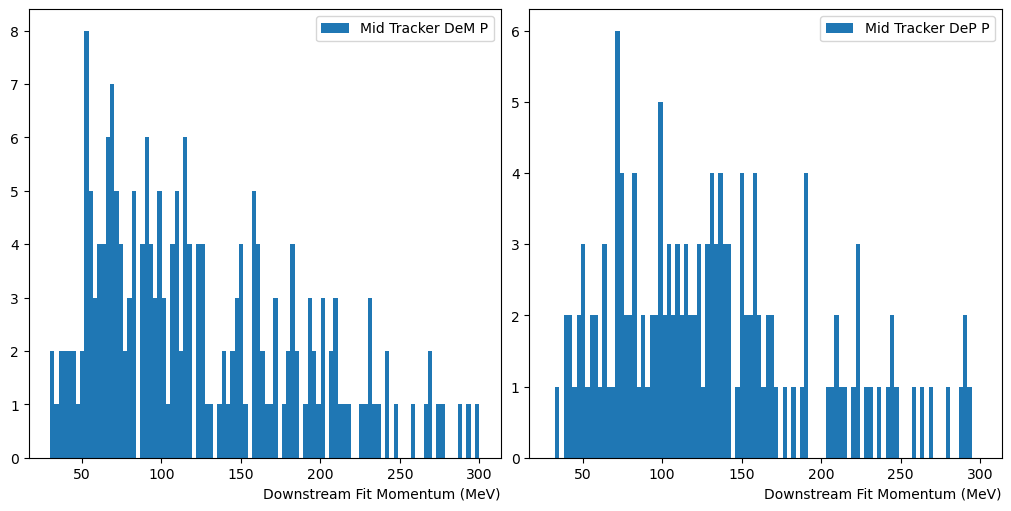

In [7]:
fig, (dem_p, dep_p )  = plt.subplots(1,2,layout='constrained', figsize=(10,5))
dem_p.hist(dem_mid_mom,label="Mid Tracker DeM P",bins=100,range=(30,300))
dem_p.set_xlabel("Downstream Fit Momentum (MeV)",loc='right')
dem_p.legend()
dep_p.hist(dep_mid_mom,label="Mid Tracker DeP P",bins=100,range=(30,300))
dep_p.set_xlabel("Downstream Fit Momentum (MeV)",loc='right')
dep_p.legend()

In [8]:
trkmcsim = batch["trkmcsim"][:,0]
print(trkmcsim)
trkmcvd = batch["trkmcvd"][:,0]
print(trkmcvd)
mcdem_mid_px = []
mcdem_mid_py = []
mcdem_mid_pz = []


[[{valid: True, nhits: 68, nactive: 68, rank: 0, pdg: 13, ...}, ...], ...]
[[{vid: 13, sid: 0, iinter: 0, time: 1.89e+04, de: 0, dp: 0, ...}, ...], ...]
